# Lab 4 — Data Quality Assessment & Preprocessing
Dataset: `world_university_survey_dataset_with_missing.csv`

This notebook completes Tasks 1–5 (missing values, outliers via IQR, normalization, and PCA).
- **Task 1** Identify data quality issues in the dataset.
- **Task 2** Apply one missing value strategy and explain why.
- **Task 3** Detect and handle outliers using IQR.
- **Task 4** Normalize numerical features using both Min-Max and Z-score.
- **Task 5** Apply PCA and interpret explained variance.

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)


## Load the dataset

In [2]:
df = pd.read_csv("world_university_survey_dataset_with_missing.csv")
df.head(10)


,student_id,student_name,age,gender,country,university,program_level,field_of_study,year_of_study,tuition_usd,scholarship,online_classes,campus_facilities_rating,teaching_quality_rating,overall_satisfaction
0,1,Dustin Shaw,30.0,Other,Netherlands,"Herrera, Juarez and Williams University",Bachelor,Data Science,5.0,47419.0,Yes,No,1.0,2.0,Satisfied
1,2,Richard Hughes,20.0,Female,UK,Norton LLC University,Master,Computer Science,4.0,6419.0,Yes,Yes,3.0,4.0,Satisfied
2,3,John Cooper,34.0,Female,UK,Berg Inc University,PhD,Engineering,3.0,7126.0,Yes,No,3.0,5.0,Very Dissatisfied
3,4,Travis Thompson,19.0,Female,Japan,Johnson-Gordon University,Bachelor,Business,2.0,13564.0,No,Yes,4.0,4.0,Dissatisfied
4,5,Jessica Campbell,34.0,Female,Japan,Nixon-Dodson University,PhD,Social Sciences,3.0,2531.0,Yes,Yes,5.0,3.0,Dissatisfied
5,6,Kristin Thompson,19.0,Other,Japan,Page LLC University,Master,Data Science,3.0,21558.0,Yes,Yes,1.0,4.0,Very Dissatisfied
6,7,Laura Stephens,34.0,Male,France,"Smith, Ferrell and Curtis University",PhD,Physics,5.0,48252.0,No,Yes,1.0,1.0,Dissatisfied
7,8,Mary Scott,25.0,Female,India,"Johnson, Malone and Brown University",PhD,Medicine,2.0,46233.0,Yes,No,1.0,5.0,Very Dissatisfied
8,9,Peter Fernandez,29.0,Male,UAE,Martinez-Perez University,Bachelor,Business,1.0,17725.0,No,Yes,2.0,2.0,Neutral
9,10,Mark Gibson,20.0,Other,Germany,"Henry, Jones and Anderson University",Master,Business,1.0,5089.0,Yes,No,5.0,5.0,Neutral


## Task 1 — Identify data quality issues
- Check data types
- Check missing values
- Quick summary for numeric columns

In [3]:
df.dtypes


student_id                    int64
student_name                 object
age                         float64
gender                       object
country                      object
university                   object
program_level                object
field_of_study               object
year_of_study               float64
tuition_usd                 float64
scholarship                  object
online_classes               object
campus_facilities_rating    float64
teaching_quality_rating     float64
overall_satisfaction         object
dtype: object

In [4]:
df.isna().sum()


student_id                  0
student_name                0
age                         1
gender                      0
country                     0
university                  0
program_level               0
field_of_study              0
year_of_study               3
tuition_usd                 2
scholarship                 0
online_classes              0
campus_facilities_rating    3
teaching_quality_rating     1
overall_satisfaction        0
dtype: int64

In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
student_name,1000,988,James Thompson,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,999.0,NaN,NaN,NaN,26.165165,5.488898,17.0,21.0,26.0,31.0,35.0
gender,1000,3,Male,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,1000,14,China,93,NaN,NaN,NaN,NaN,NaN,NaN,NaN
university,1000,968,Johnson PLC University,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
program_level,1000,3,Master,353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
field_of_study,1000,10,Computer Science,119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year_of_study,997.0,NaN,NaN,NaN,2.967904,1.377156,1.0,2.0,3.0,4.0,5.0
tuition_usd,998.0,NaN,NaN,NaN,25642.028056,13940.295811,2008.0,13241.5,26139.0,37424.5,49975.0


## Convert incorrect data types (light cleanup)
We ensure key numerical columns are numeric so we can impute, detect outliers, scale, and run PCA.

In [6]:
# Convert to numeric safely (invalid parsing -> NaN)
df["tuition_usd"] = pd.to_numeric(df["tuition_usd"], errors="coerce")
df["overall_satisfaction"] = pd.to_numeric(df["overall_satisfaction"], errors="coerce")

df.dtypes


student_id                    int64
student_name                 object
age                         float64
gender                       object
country                      object
university                   object
program_level                object
field_of_study               object
year_of_study               float64
tuition_usd                 float64
scholarship                  object
online_classes               object
campus_facilities_rating    float64
teaching_quality_rating     float64
overall_satisfaction        float64
dtype: object

## Task 2 — Apply ONE missing value strategy
We will use **mean imputation** for the numerical column `tuition_usd`.

First, (optional) create a copy and add some missing values to demonstrate the strategy.

In [7]:
df_missing = df.copy()
df_missing.loc[0:5, "tuition_usd"] = np.nan

df_missing.isna().sum()


student_id                     0
student_name                   0
age                            1
gender                         0
country                        0
university                     0
program_level                  0
field_of_study                 0
year_of_study                  3
tuition_usd                    8
scholarship                    0
online_classes                 0
campus_facilities_rating       3
teaching_quality_rating        1
overall_satisfaction        1000
dtype: int64

In [8]:
# Mean imputation
df_imputed = df_missing.copy()
df_imputed["tuition_usd"] = df_imputed["tuition_usd"].fillna(df_imputed["tuition_usd"].mean())

df_imputed.isna().sum()


student_id                     0
student_name                   0
age                            1
gender                         0
country                        0
university                     0
program_level                  0
field_of_study                 0
year_of_study                  3
tuition_usd                    0
scholarship                    0
online_classes                 0
campus_facilities_rating       3
teaching_quality_rating        1
overall_satisfaction        1000
dtype: int64

## Task 3 — Detect and handle outliers using IQR
We detect outliers in `tuition_usd` using the IQR rule and then remove them.

In [9]:
Q1 = df_imputed["tuition_usd"].quantile(0.25)
Q3 = df_imputed["tuition_usd"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

lower, upper


(np.float64(-22233.25), np.float64(73060.75))

In [10]:
outliers = df_imputed[(df_imputed["tuition_usd"] < lower) | (df_imputed["tuition_usd"] > upper)]
outliers.head(15)


,student_id,student_name,age,gender,country,university,program_level,field_of_study,year_of_study,tuition_usd,scholarship,online_classes,campus_facilities_rating,teaching_quality_rating,overall_satisfaction


In [11]:
df_no_outliers = df_imputed[(df_imputed["tuition_usd"] >= lower) & (df_imputed["tuition_usd"] <= upper)].copy()

print("Before outlier removal:", df_imputed.shape)
print("After outlier removal :", df_no_outliers.shape)


Before outlier removal: (1000, 15)
After outlier removal : (1000, 15)


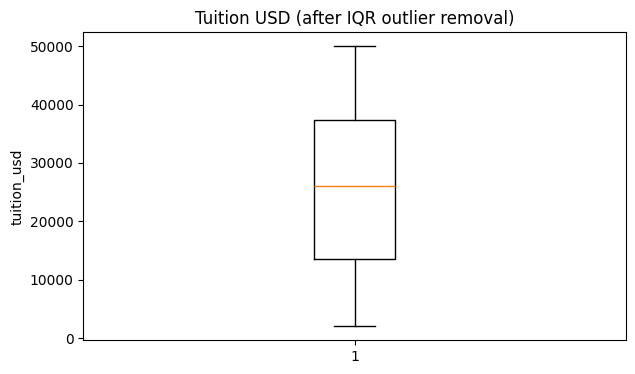

In [12]:
# Simple boxplot (for visual confirmation)
plt.figure(figsize=(7,4))
plt.boxplot(df_no_outliers["tuition_usd"].dropna())
plt.title("Tuition USD (after IQR outlier removal)")
plt.ylabel("tuition_usd")
plt.show()


## Task 4 — Normalize numerical features (Min-Max and Z-score)
We will normalize these numerical columns:
- `tuition_usd`
- `overall_satisfaction`

In [13]:
numeric_cols = ["tuition_usd", "overall_satisfaction"]

# Keep only needed columns (drop rows where any is missing for scaling/PCA)
df_model = df_no_outliers[numeric_cols].dropna().copy()
df_model.head()


,tuition_usd,overall_satisfaction


In [ ]:
numeric_cols = ['tuition_usd', 'teaching_quality_rating'] 

df_model = df_no_outliers[numeric_cols].apply(pd.to_numeric, errors='coerce').dropna().copy()

minmax = MinMaxScaler()
df_minmax = df_model.copy()
df_minmax[numeric_cols] = minmax.fit_transform(df_minmax[numeric_cols])

df_minmax.head()

,tuition_usd,teaching_quality_rating
0,0.493875,0.25
1,0.493875,0.75
2,0.493875,1.00
3,0.493875,0.75
4,0.493875,0.50


In [20]:
zscaler = StandardScaler()
df_zscore = df_model.copy()
df_zscore[numeric_cols] = zscaler.fit_transform(df_zscore[numeric_cols])

df_zscore.head()


,tuition_usd,teaching_quality_rating
0,0.001002,-0.664572
1,0.001002,0.749501
2,0.001002,1.456538
3,0.001002,0.749501
4,0.001002,0.042465


## Task 5 — PCA and explained variance
We apply PCA on the **Z-score standardized** data (common practice).

In [21]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_zscore[numeric_cols])

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())


Explained Variance Ratio: [0.51385655 0.48614345]
Total explained variance: 1.0


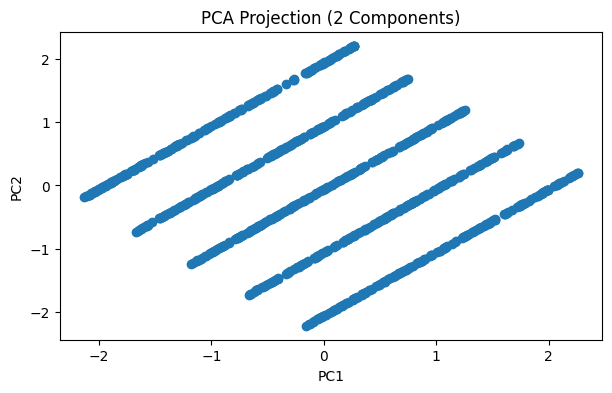

In [22]:
# PCA scatter plot
plt.figure(figsize=(7,4))
plt.scatter(principal_components[:, 0], principal_components[:, 1])
plt.title("PCA Projection (2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
